In [ ]:
import kagglehub

# Lien pour les données sur kaggle
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [ ]:
import pandas as pd
#Table pour fake news
fake = pd.read_csv(path + "/Fake.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
fake["text"][0]

'Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t ev

In [ ]:
#Table pour Vrai news
real = pd.read_csv(path + "/True.csv")
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
print(fake.shape, real.shape)

(23481, 4) (21417, 4)


In [ ]:
# Ajout des labels pour les classes
fake['label'] = 0
real['label'] = 1

# Melange des deux tableaux
df = pd.concat([fake, real], ignore_index=True)
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
# Split dataset
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

# Text preprocessing
max_words = 10000
max_len = 500

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [ ]:
import pickle

# Sauvegarde du tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [ ]:
# Build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, History
model_lstm = Sequential()
model_lstm.add(Embedding(max_words, 128, input_length=max_len))
model_lstm.add(LSTM(64, dropout=0.5, recurrent_dropout=0.5, kernel_regularizer=l2(0.01)))
model_lstm.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01)))

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = History()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

model_lstm.fit(X_train_pad, y_train, epochs=5, batch_size=128, validation_split=0.2, callbacks=[history, early_stopping])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.8452 - loss: 1.1417 - val_accuracy: 0.9683 - val_loss: 0.1785
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.9675 - loss: 0.1863 - val_accuracy: 0.9781 - val_loss: 0.1540
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.9726 - loss: 0.1784 - val_accuracy: 0.9784 - val_loss: 0.1370
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.9804 - loss: 0.1422 - val_accuracy: 0.9815 - val_loss: 0.1257
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.9827 - loss: 0.1277 - val_accuracy: 0.9720 - val_loss: 0.1509
Restoring model weights from the end of the best epoch: 4.


In [ ]:
model_lstm.save("lstm_model.h5")

281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4733
           1       0.96      0.99      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



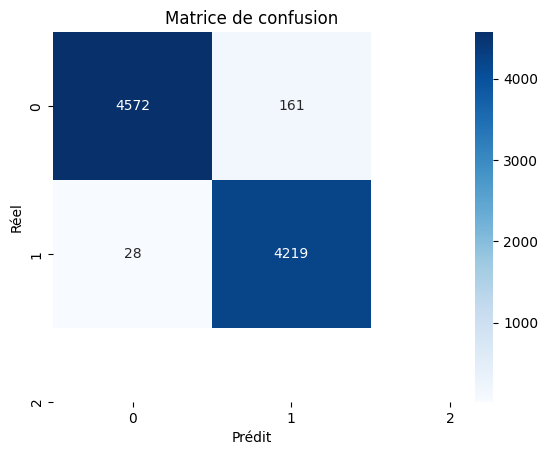

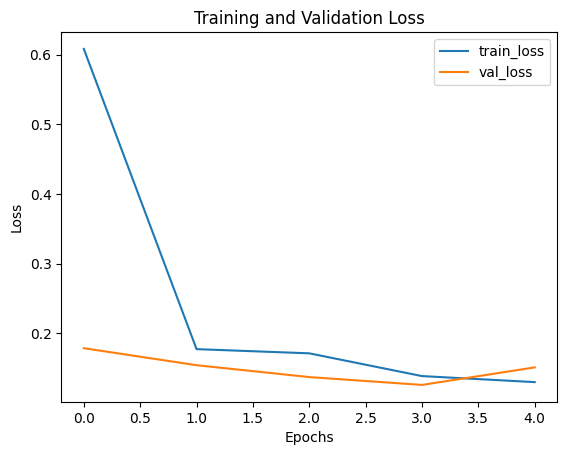

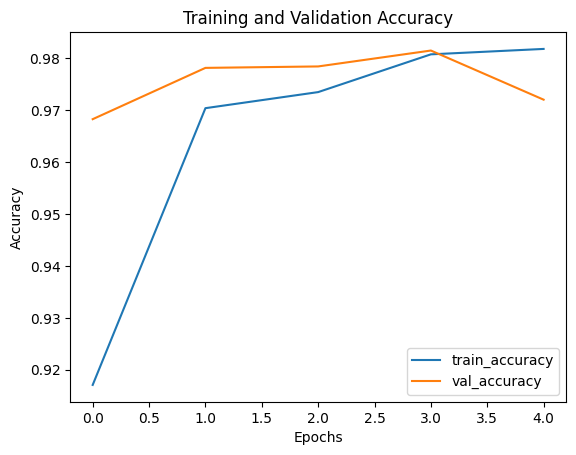

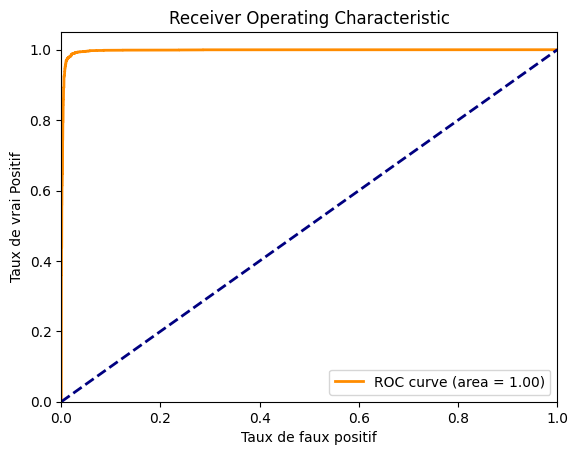

In [ ]:
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y_pred_prob = model_lstm.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Compute evaluation metrics
print(classification_report(y_test, y_pred))

# Matrice de confusion
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

# Plot training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positif')
plt.ylabel('Taux de vrai Positif')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#**Objectif : Lancer GPT-2 pour générer des textes adversariaux**

In [ ]:
#On extrait les fake news pour entraîner le générateur SeqGAN
fake_news = fake["text"].dropna().tolist()

with open("fake_news.txt", "w", encoding="utf-8") as f:
    for line in fake_news:
        f.write(line.strip() + "\n")


In [ ]:
!pip install transformers

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Charger GPT-2
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
!pip install datasets
from datasets import load_dataset
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Créer un dataset à partir du fichier fake news
dataset = load_dataset("text", data_files={"train": "fake_news.txt"})

# Tokenization
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from transformers import GPT2LMHeadModel, TrainingArguments, Trainer
import torch

# Adapter le modèle au tokenizer
model.resize_token_embeddings(len(tokenizer))

#  Réduire le dataset pour un test rapide
small_dataset = tokenized_dataset["train"].select(range(1000))

# Arguments d'entraînement allégés
training_args = TrainingArguments(
    output_dir="./gpt2-fake-news",
    overwrite_output_dir=True,
    max_steps=200,  # Limite le nombre de steps
    per_device_train_batch_size=2,
    save_steps=100,
    save_total_limit=1,
    logging_steps=10,
)

# Collation des données
def data_collator(features):
    return {
        'input_ids': torch.tensor([f['input_ids'] for f in features]),
        'attention_mask': torch.tensor([f['attention_mask'] for f in features]),
        'labels': torch.tensor([f['input_ids'] for f in features]),
    }

# Entraîneur
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

# Démarrer l'entraînement
trainer.train()


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-8-0c21d086cf7c>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,3.623100
20,3.464000
30,3.348900
40,3.530700
50,3.338800
60,3.613900
70,3.381800
80,3.362900
90,3.469800
100,3.497700


TrainOutput(global_step=200, training_loss=3.411021327972412, metrics={'train_runtime': 1177.4025, 'train_samples_per_second': 0.34, 'train_steps_per_second': 0.17, 'total_flos': 26129203200000.0, 'train_loss': 3.411021327972412, 'epoch': 0.4})

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Recharger le modèle et le tokenizer sauvegardés
model = GPT2LMHeadModel.from_pretrained("./gpt2-fake-news-small")
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2-fake-news-small")

# Passage en mode évaluation
model.eval()

# Prompt de départ (début d’une fake news)
prompt = "Breaking news: "

# Encodage
inputs = tokenizer(prompt, return_tensors="pt")

# Génération du texte
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=75,
        num_return_sequences=75,         # Générer 75 fake news différentes
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id  # pour éviter les warnings
    )

# Affichage des résultats
generated_texts = []

for i, output in enumerate(outputs):
    text = tokenizer.decode(output, skip_special_tokens=True)
    print(f"\nFake news #{i+1}:\n{text}")
    generated_texts.append(text)


Fake news #1:
Breaking news:  Donald Trump s Twitter account says that Trump s daughter Ivanka will attend a rally in Iowa on Saturday, and it looks like he's already making the decision to ban immigrants from certain Muslim countries.  It would be bad enough, but if Ivanka Trump is truly in the U.S. she should get her own country on Trump s list!  

Fake news #2:
Breaking news:  Donald Trump is the GOP's favorite Donald Trump. I had the great pleasure of meeting with him in the Oval Office, and I know there were a lot of people in the office who thought that is exactly true, right?The real estate mogul and reality TV star is a man with a bizarre, sordid past, an uncharacteristic lack of

Fake news #3:
Breaking news:  The Senate Judiciary Committee approved a bill that would give the Federal Bureau of Investigation the power to subpoena all phone records held of U.S. citizens. It also allows the FBI to obtain records that are part of criminal investigations of Russian interference in 

##**Evaluation du modèle LSTM sur les données générées**

In [ ]:
# Chargement du tokenizer
import pickle
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


In [ ]:
!pip install nltk
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequences_fake = tokenizer.texts_to_sequences(generated_texts)
#maxlen = 500   la meme valeur que dans le modèle
X_fake = pad_sequences(sequences_fake, maxlen=max_len)


In [ ]:
print(sequences_fake)

[[1915, 102, 71, 16, 9, 141, 953, 200, 8, 16, 9, 1353, 2052, 40, 1920, 5, 724, 7, 1537, 10, 529, 6, 15, 1404, 90, 9039, 307, 372, 2, 298, 3, 547, 670, 26, 1168, 330, 278, 15, 36, 23, 682, 488, 33, 57, 2052, 16, 12, 1981, 7, 2, 38, 9, 52, 114, 134, 55, 222, 112, 10, 16, 9, 699], [1915, 102, 71, 16, 12, 2, 1, 2658, 71, 16, 34, 43, 2, 385, 1, 4, 271, 17, 79, 7, 2, 2904, 173, 6, 34, 168, 66, 47, 5, 518, 4, 46, 7, 2, 173, 30, 725, 8, 12, 1124, 811, 135, 2, 399, 1561, 3723, 6, 968, 757, 1048, 12, 5, 250, 17, 5, 3752, 1, 403, 31, 1, 1352, 4], [1915, 102, 2, 164, 1789, 233, 1242, 5, 158, 8, 36, 428, 2, 178, 1556, 4, 276, 2, 261, 3, 4967, 56, 999, 1153, 417, 4, 38, 9, 596, 15, 62, 2423, 2, 269, 3, 3417, 1153, 8, 29, 205, 4, 683, 1599, 4, 195, 2059, 7, 2, 202, 149, 99, 27, 158, 36, 642, 2, 269, 3, 1, 519, 3, 765, 103, 286, 32, 24, 8, 86], [1915, 102, 15, 264, 107, 53, 85, 3, 6519, 2, 80, 104, 521, 302, 47, 3250, 3, 569, 8, 2762, 1727, 9, 91, 73, 9, 1, 18, 53, 4, 42, 222, 372, 32, 47, 5098, 6, 2,

In [ ]:
import numpy as np

# Prédictions
pred_fake = model_lstm.predict(X_fake)

y_pred = (pred_fake > 0.5).astype(int)
nb_fake = np.sum(y_pred == 0)
nb_reel = np.sum(y_pred == 1)
precis=(nb_fake*100)/len(y_pred)
#print(pred_fake)
print(f"Nombre de phrases classées comme FAKE : {nb_fake}")
print(f"Nombre de phrases classées comme RÉELLES : {nb_reel}")
print(f"Precision_fake_gpt-2: {precis} %")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Nombre de phrases classées comme FAKE : 28
Nombre de phrases classées comme RÉELLES : 47
Precision_fake_gpt-2: 37.333333333333336 %


#**Fine-tuning du modèle LSTM**
On continue l'entraînement avec les 50 fakes news générés.

In [ ]:
import pandas as pd

# on prend 50 true news aléatoirement
real_text=real["text"]
real_sample = real_text.sample(n=75, random_state=42).copy()
label_1 = np.ones((len(real_sample), 1), dtype=np.float32)
real_df=pd.DataFrame(real_sample, columns=["text"])
real_df["label"]=label_1
# Étape 2 : création du DataFrame des fake news
fake_sample = generated_texts
label_2 = np.zeros((len(fake_sample), 1), dtype=np.float32)
fake_df=pd.DataFrame(fake_sample, columns=["text"])
fake_df["label"]=label_2
# fusion

df_balanced = pd.concat([real_df, fake_df], ignore_index=True)


In [ ]:
df_balanced.tail()

,text,label
145,Breaking news: America finally found a good o...,0.0
146,Breaking news: Donald J. Trump has not actua...,0.0
147,Breaking news: A federal judge has issued his...,0.0
148,Breaking news: President Trump s response wa...,0.0
149,Breaking news: There will not be a Senate Re...,0.0


In [ ]:
import pickle

# 1. Tokenisation
tokenizer.fit_on_texts(df_balanced["text"])

# 2. Séquences
sequences = tokenizer.texts_to_sequences(df_balanced["text"])
label=df_balanced["label"]
# 3. Padding
X_2 = pad_sequences(sequences, maxlen=max_len)
y_2= df_balanced["label"]
# 3. Split entraînement/test
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2, y_2, test_size=0.2, stratify=y_2, random_state=42
)


print("X_train shape:", X_train2.shape)
print("X_test shape:", X_test2.shape)
print("Label distribution in train:", dict(zip(*np.unique(y_train, return_counts=True))))


X_train shape: (120, 500)
X_test shape: (30, 500)
Label distribution in train: {np.int64(0): np.int64(18748), np.int64(1): np.int64(17170)}


In [ ]:

# Fit the model
history = model_lstm.fit(
    X_train2,
    y_train2,
    epochs=5,
    batch_size=16,
    validation_data=(X_test2, y_test2)
)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 793ms/step - accuracy: 0.8462 - loss: 0.4919 - val_accuracy: 0.9667 - val_loss: 0.2323
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 638ms/step - accuracy: 0.9169 - loss: 0.3318 - val_accuracy: 1.0000 - val_loss: 0.1880
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 736ms/step - accuracy: 0.9422 - loss: 0.2918 - val_accuracy: 0.9333 - val_loss: 0.2822
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 616ms/step - accuracy: 0.9389 - loss: 0.2407 - val_accuracy: 1.0000 - val_loss: 0.1635
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 796ms/step - accuracy: 0.9806 - loss: 0.2036 - val_accuracy: 0.9667 - val_loss: 0.1839


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Rapport de classification :

              precision    recall  f1-score   support

        Fake       1.00      0.93      0.97        15
        Real       0.94      1.00      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



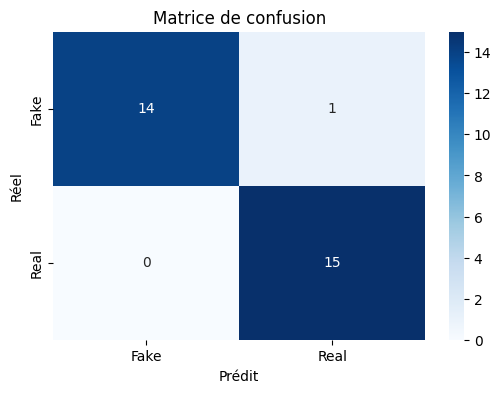

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prédictions sur les données de validation
y_pred_probs = model_lstm.predict(X_test2)
y_pred_2 = (y_pred_probs > 0.5).astype(int).flatten()

# 2. Rapport de classification
print("Rapport de classification :\n")
print(classification_report(y_test2, y_pred_2, target_names=["Fake", "Real"]))

# 3. Matrice de confusion
cm = confusion_matrix(y_test2, y_pred_2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


##**Regénération de fake et évaluation**

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Recharger le modèle et le tokenizer sauvegardés
model = GPT2LMHeadModel.from_pretrained("./gpt2-fake-news-small")
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2-fake-news-small")

# Passage en mode évaluation
model.eval()

# Prompt de départ (début d’une fake news)
prompt = " News: "

# Encodage
inputs = tokenizer(prompt, return_tensors="pt")

# Génération du texte
with torch.no_grad():
    outputs_2 = model.generate(
        **inputs,
        max_length=75,
        num_return_sequences=75,         # Générer 3 fake news différentes
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id  # pour éviter les warnings
    )

# Affichage des résultats
generated_text_2 = []

for i, output in enumerate(outputs_2):
    text = tokenizer.decode(output, skip_special_tokens=True)
    print(f"\nFake news #{i+1}:\n{text}")
    generated_text_2.append(text)


Fake news #1:
 News:  Obama s response to the Orlando attack by a gunman who killed nine people at a gay nightclub, an event that left at least 32 people dead, is the same one we hear every week.  This time around, however, the administration has been more than willing to stand with the victims and to stand with the victims' families and hope that they can get the

Fake news #2:
 News:  Donald Trump is a moron  and this is why. Trump thinks that the U.S. military should be involved in countries like China and Russia, in part because he wants to take advantage of America's position in the Asia-Pacific.  And for once, there seems to have been a bit of a response to Trump s tweet. But Trump doesn

Fake news #3:
 News:  "The White House sent out a memo Monday morning threatening to withdraw support from President Trump and the Republican Party for a man who repeatedly attacked the legitimacy of the Senate majority leader. And it warned Trump not to do that in his own country. He s a Repub

In [ ]:
# Chargement du tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

sequences_fake_2 = tokenizer.texts_to_sequences(generated_text_2)
#maxlen = 500   la meme valeur que dans le modèle
X_fake_2 = pad_sequences(sequences_fake_2, maxlen=max_len)


# Prédictions
pred_fake_2 = model_lstm.predict(X_fake_2)
#print(pred_fake)
y_pred_2 = (pred_fake_2 > 0.5).astype(int)  # binaire : 1 si prob > 0.5
nb_fake_2 = np.sum(y_pred_2 == 0)
nb_reel_2 = np.sum(y_pred_2 == 1)
precis_2=(nb_fake_2*100)/len(y_pred_2)
#print(pred_fake_2)
print(f"Nombre de phrases classées comme FAKE : {nb_fake_2}")
print(f"Nombre de phrases classées comme RÉELLES : {nb_reel_2}")
print(f"Precision_fake_gpt-2: {precis_2} %")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step
Nombre de phrases classées comme FAKE : 69
Nombre de phrases classées comme RÉELLES : 6
Precision_fake_gpt-2: 92.0 %
